# Federal new-hire heatmaps: grade × education by occupation

Each figure below shows **new federal hires** for one occupational series (or all occupations), broken out by **GS grade** (columns) and **education level** (rows).

**Data:** OPM/EHRI *accessions* (new hires) via the public HuggingFace dataset [`impactproject/opm-ehri-data`](https://huggingface.co/datasets/impactproject/opm-ehri-data), which mirrors [data.opm.gov](https://data.opm.gov/explore-data/data/data-downloads). Parquet is streamed remotely with DuckDB — nothing is downloaded to disk. Counts are `SUM(count)` over rows from **Jan 2021 to present**.

**Everything runs off one call:** `accession_heatmap("<series code>")`. Change the code, get the figure. Key options: `pay_plans` (`"gs"`, `"gs+gg"`, `"all"`), `totals`, `highlight_quals`, and `series=None` for all occupations.

In [1]:
from ehri_heatmaps import accession_heatmap

/Users/abigailhaddad/Documents/repos/pull_usaspending/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The four series in this analysis. To add another, just append its code — nothing else changes.

In [2]:
SERIES = {
    "2210": "IT Management",
    "1550": "Computer Science",
    "1560": "Data Science",
    "1530": "Statistics",
}

## GS hires only

x-axis = GS-01 … GS-15 (General Schedule pay plan only).

### Figure 1 — 2210 (IT Management)

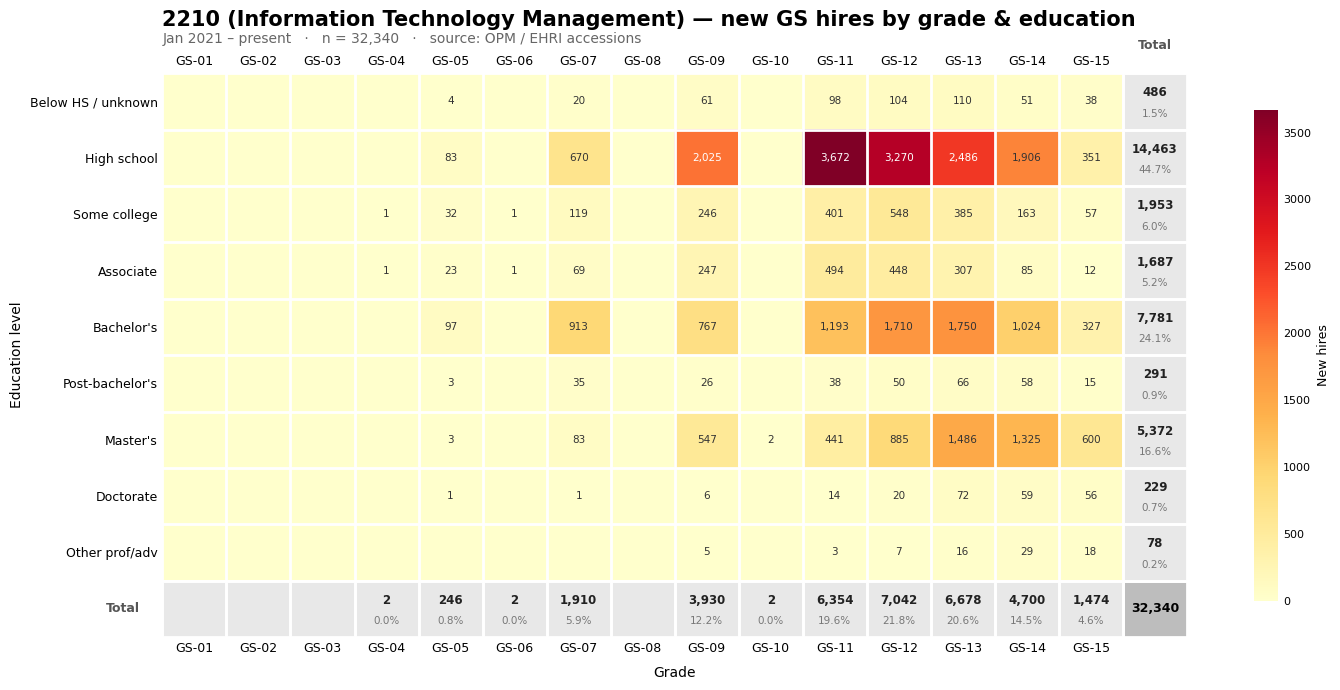

In [3]:
accession_heatmap("2210");

### Figure 2 — 1550 (Computer Science)

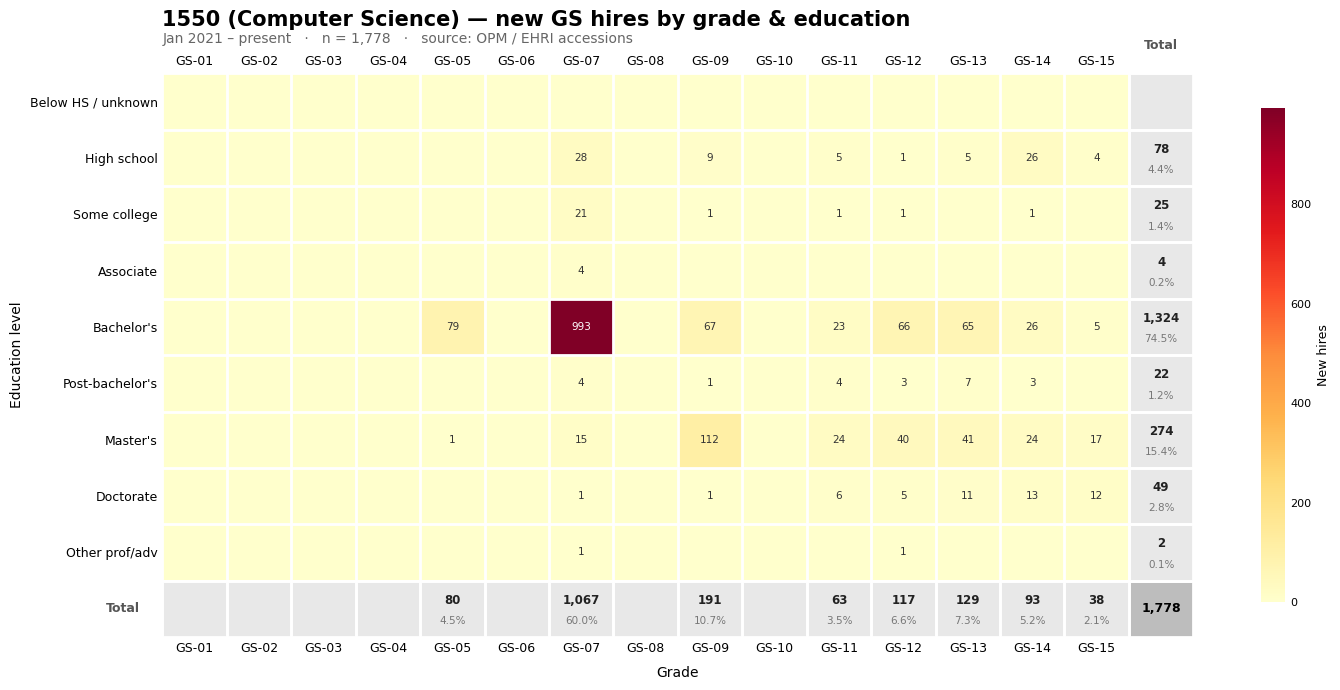

In [4]:
accession_heatmap("1550");

### Figure 3 — 1560 (Data Science)

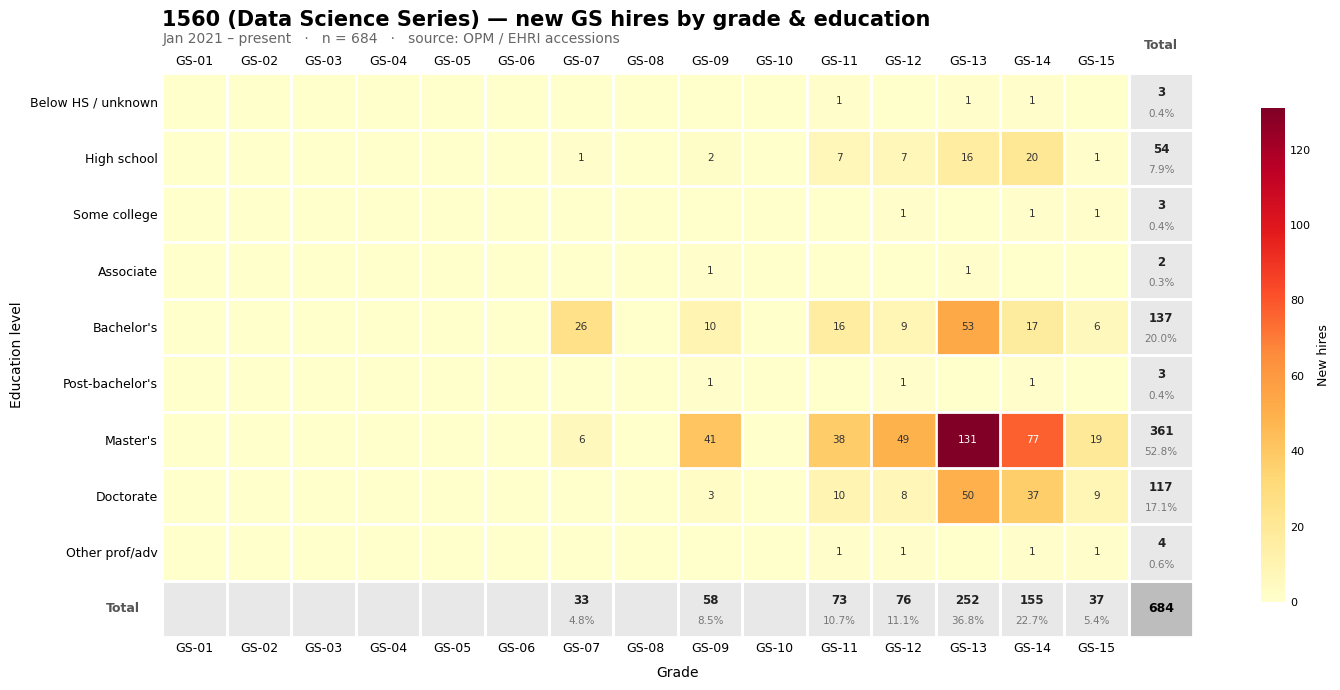

In [5]:
accession_heatmap("1560");

### Figure 4 — 1530 (Statistics)

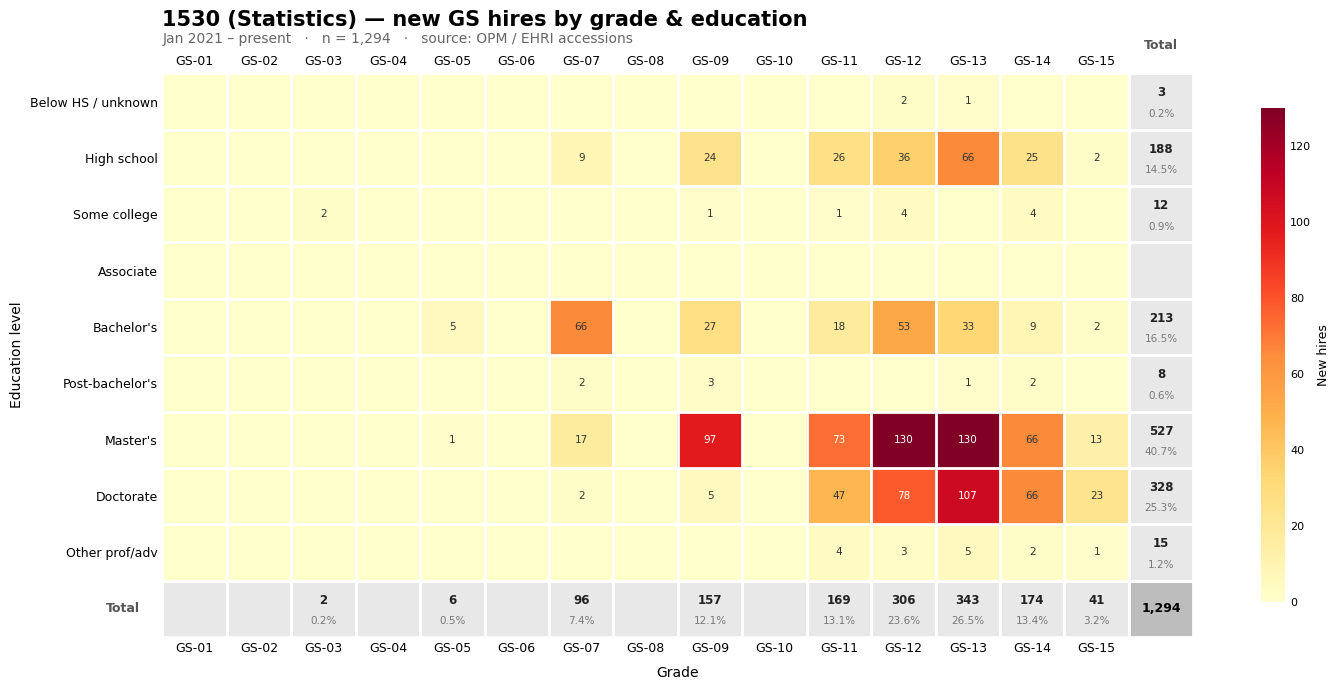

In [6]:
accession_heatmap("1530");

## All pay plans

GS **and GG** share the GS grade scale; every other pay plan (demonstration bands, AD, FV, …) is pooled into a single **"Other plans"** column because their grade numbers aren't comparable to GS grades.

### Figure 5 — 2210 (IT Management), all pay plans

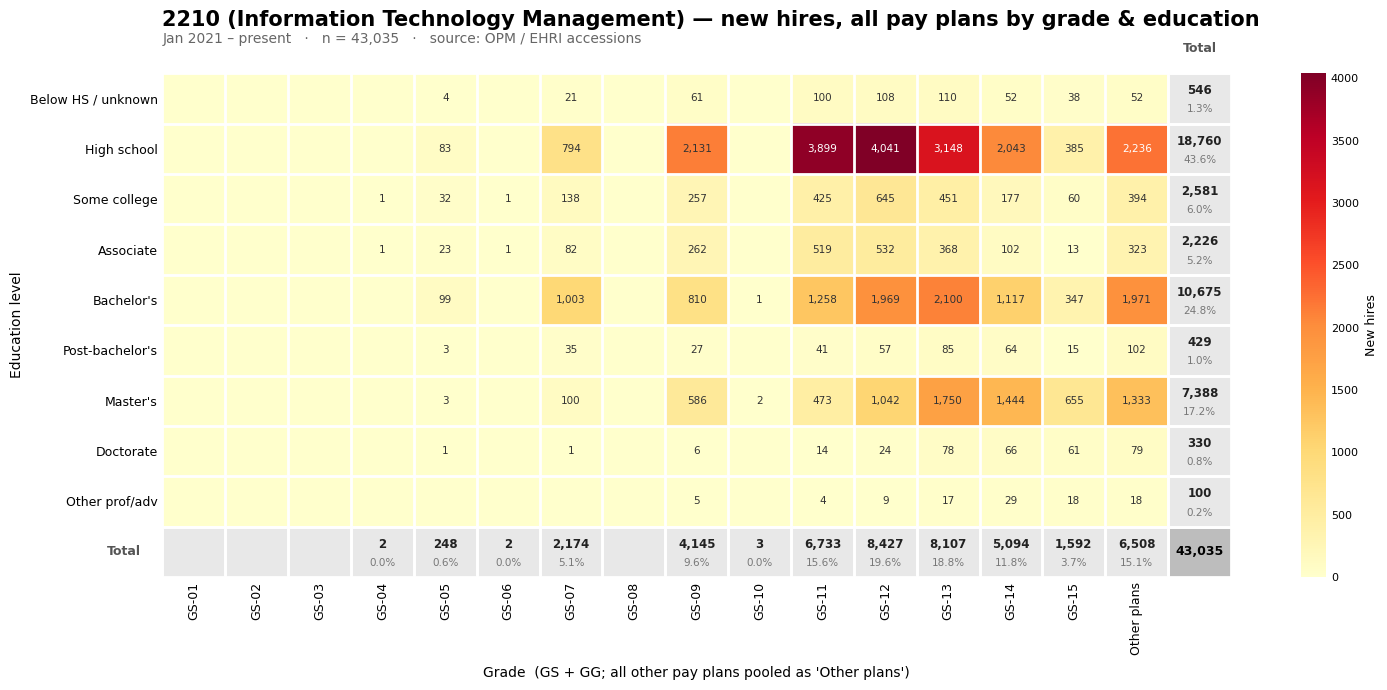

In [7]:
accession_heatmap("2210", all_plans=True);

### Figure 6 — 1550 (Computer Science), all pay plans

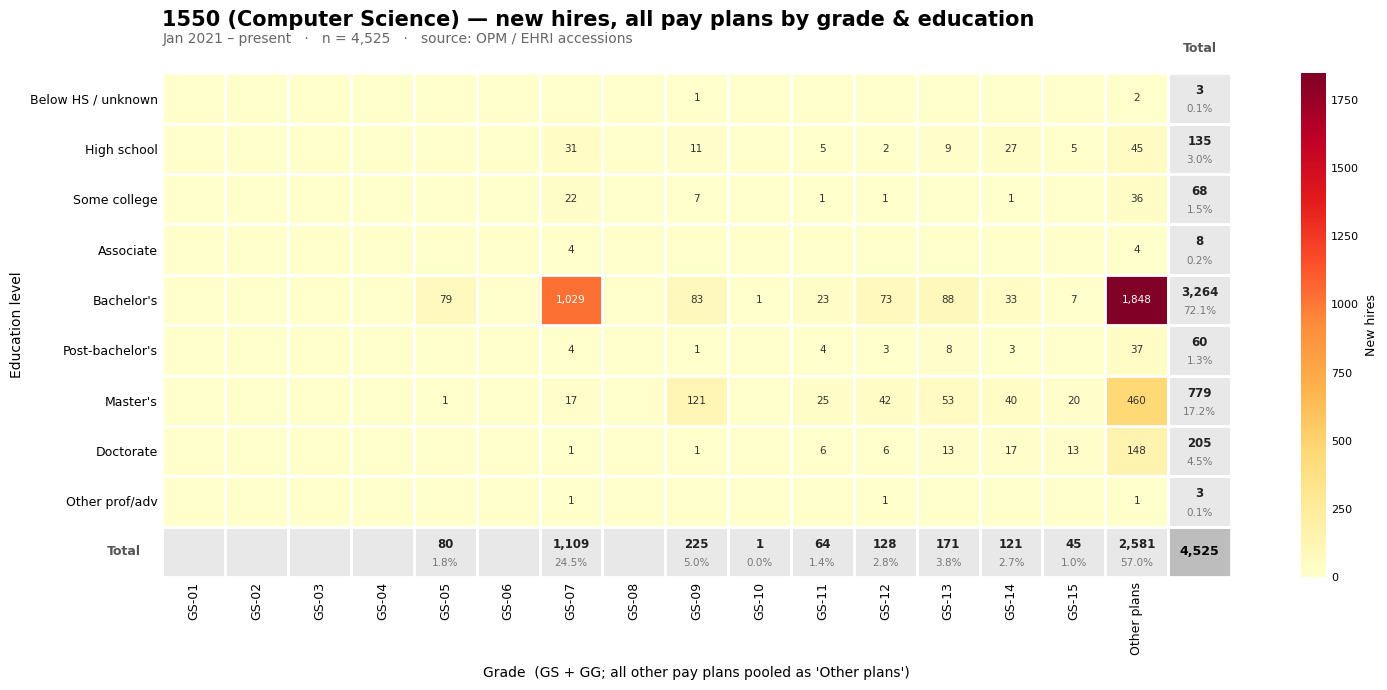

In [8]:
accession_heatmap("1550", all_plans=True);

### Figure 7 — 1560 (Data Science), all pay plans

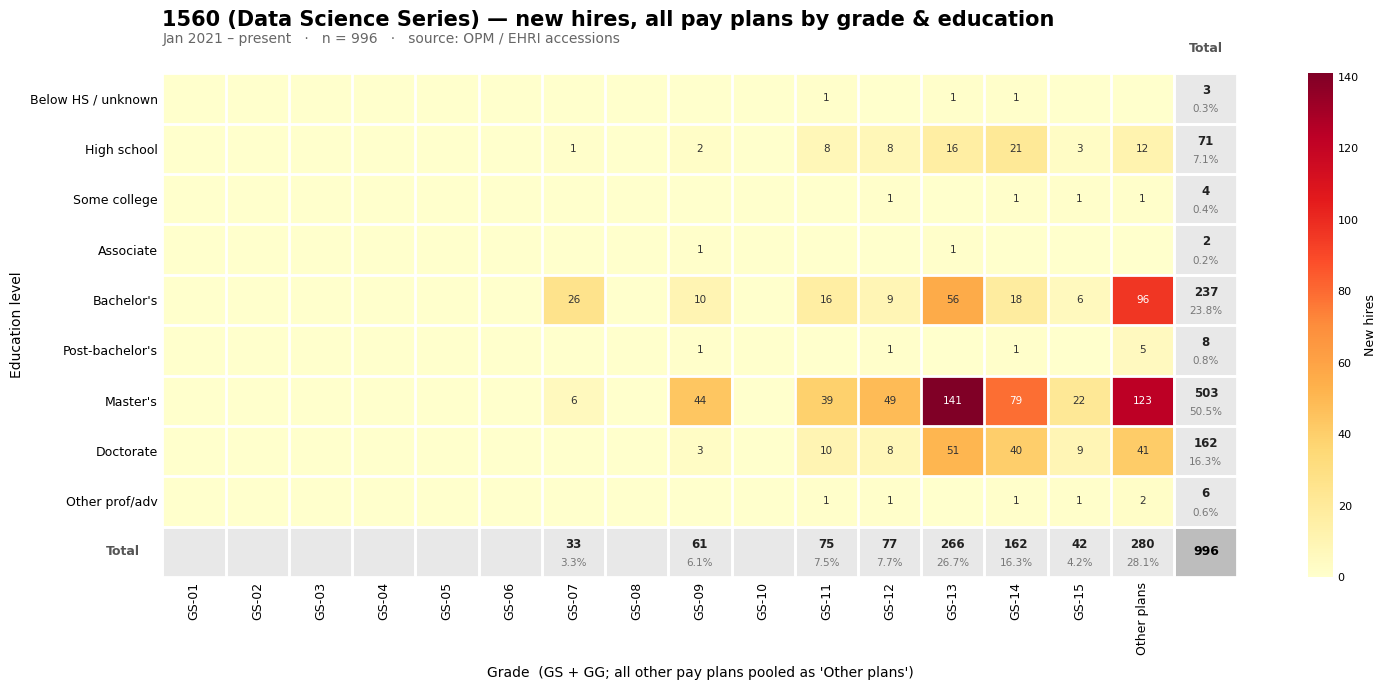

In [9]:
accession_heatmap("1560", all_plans=True);

### Figure 8 — 1530 (Statistics), all pay plans

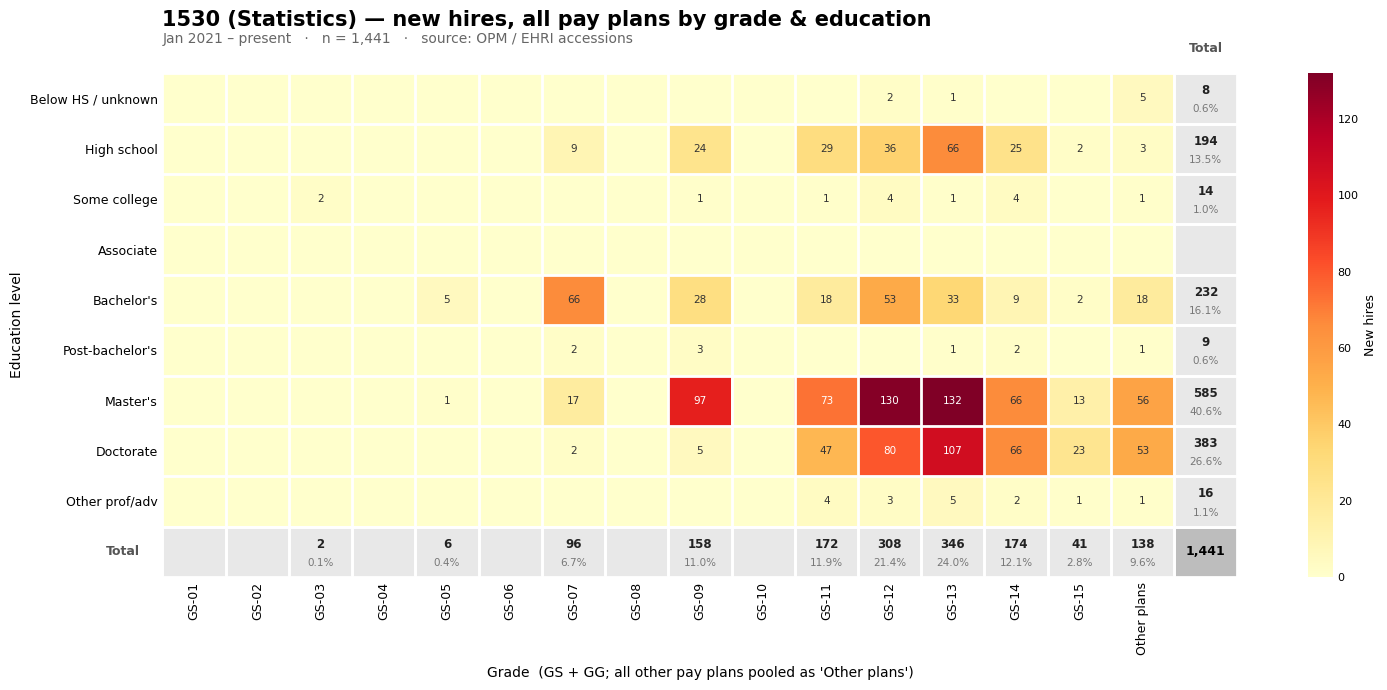

In [10]:
accession_heatmap("1530", all_plans=True);

## Could the degree alone have qualified them?

OPM's group-coverage standard for professional work lets education substitute for experience at specific grades: a **bachelor's** opens **GS-5** (and **GS-7** with superior academic achievement / 1 yr graduate study), a **master's** opens **GS-9**, and a **Ph.D.** opens **GS-11**. Because a higher degree also satisfies the lower thresholds, the **outlined** cells form a staircase — a master's covers GS-5/7/9, a Ph.D. covers GS-5/7/9/11. The box reports the share of hires landing in any outlined cell, where the credential *could* be the basis of qualification.

These use **GS + GG** (comparable grade scale), counts only, no totals.

### Figure 9 — All occupations (GS + GG)

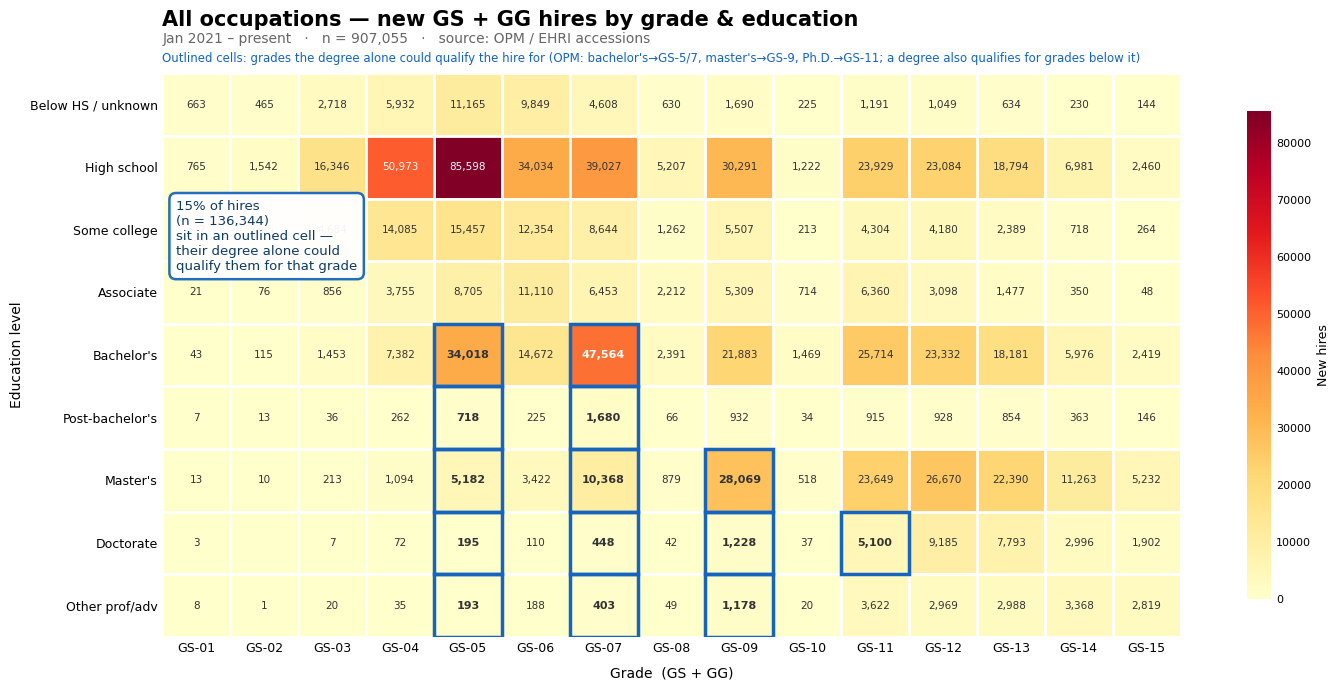

In [11]:
accession_heatmap(pay_plans="gs+gg", totals=False, highlight_quals=True);

### Figure 10 — 2210 (IT Management), GS + GG

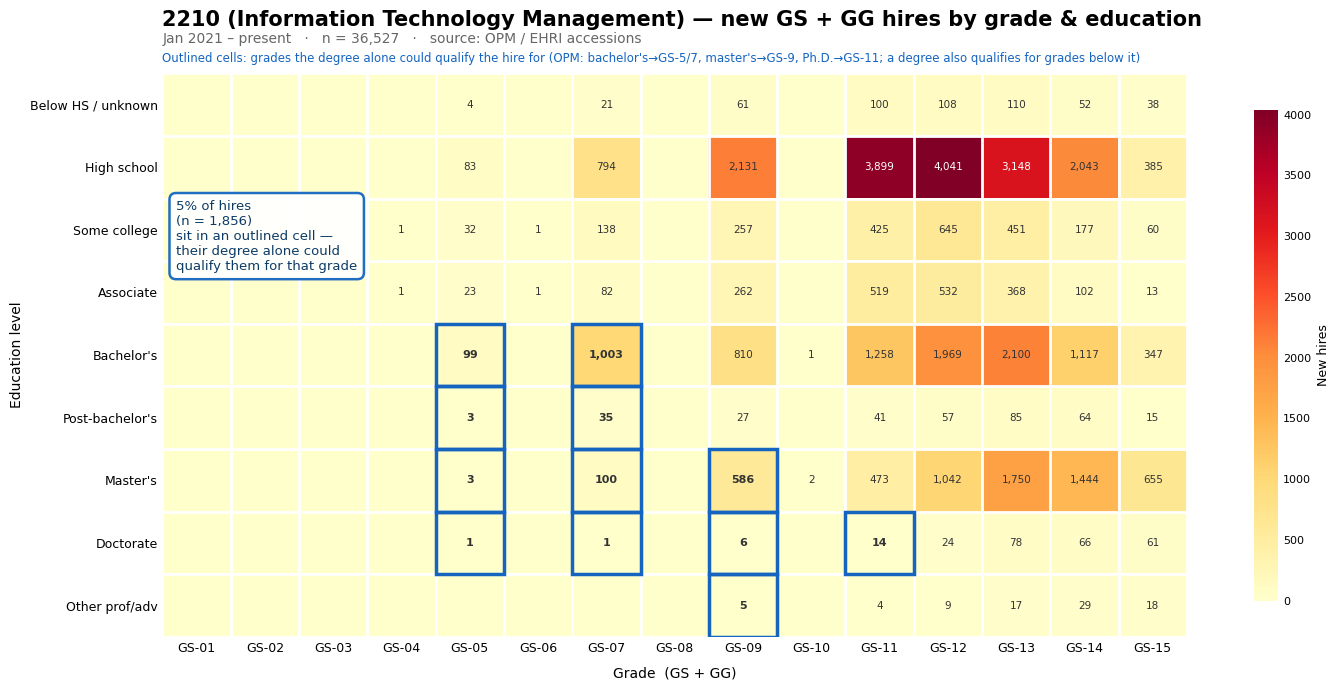

In [12]:
accession_heatmap("2210", pay_plans="gs+gg", totals=False, highlight_quals=True);

## Save figures to disk (optional)

Pass `save=True` (or `out="path.png"`) to write a PNG for the article.

wrote heatmap_2210.png


wrote heatmap_2210_allplans.png


wrote heatmap_1550.png


wrote heatmap_1550_allplans.png


wrote heatmap_1560.png


wrote heatmap_1560_allplans.png


wrote heatmap_1530.png


wrote heatmap_1530_allplans.png


wrote heatmap_overall_gsgg_quals.png


wrote heatmap_2210_gsgg_quals.png


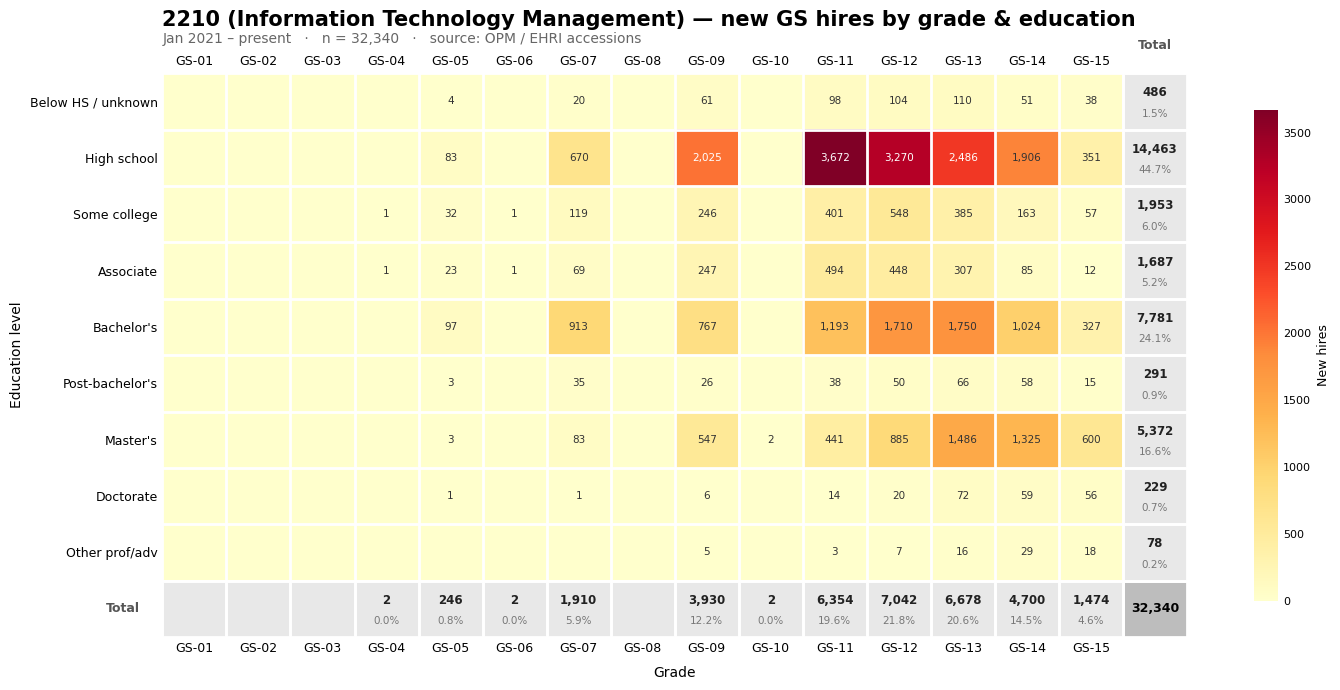

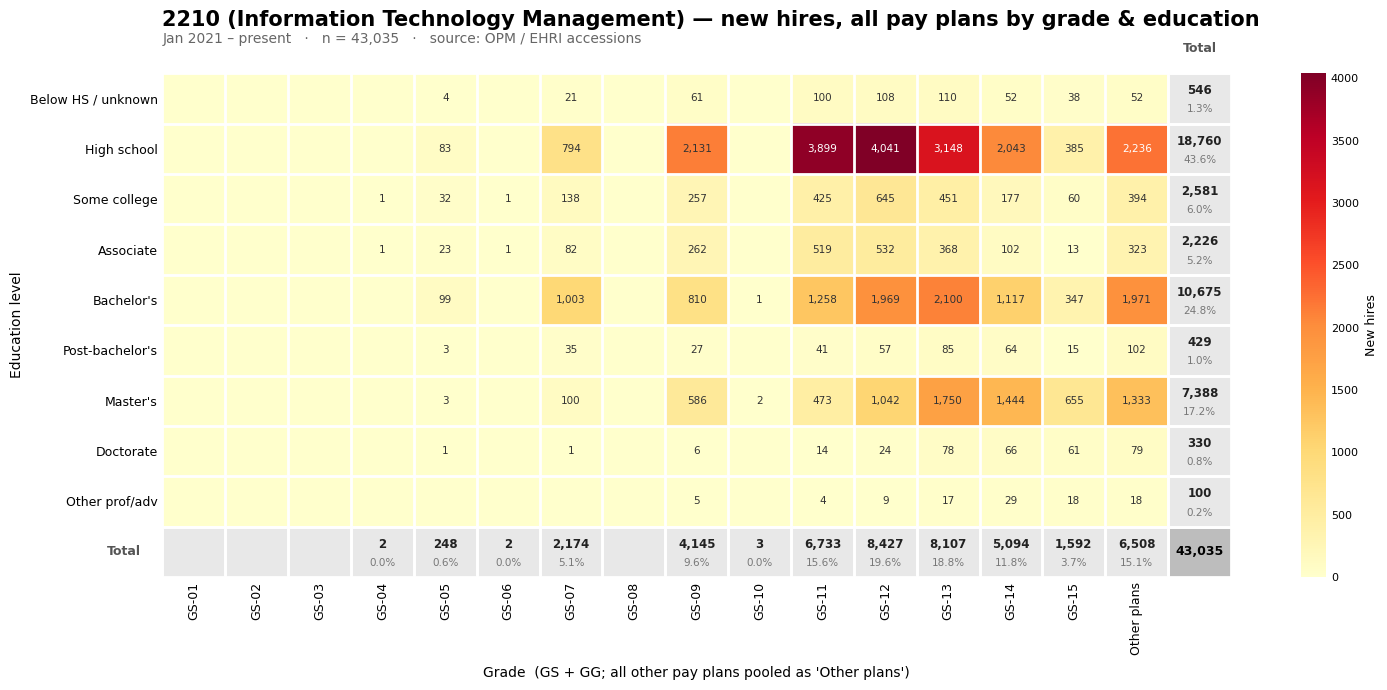

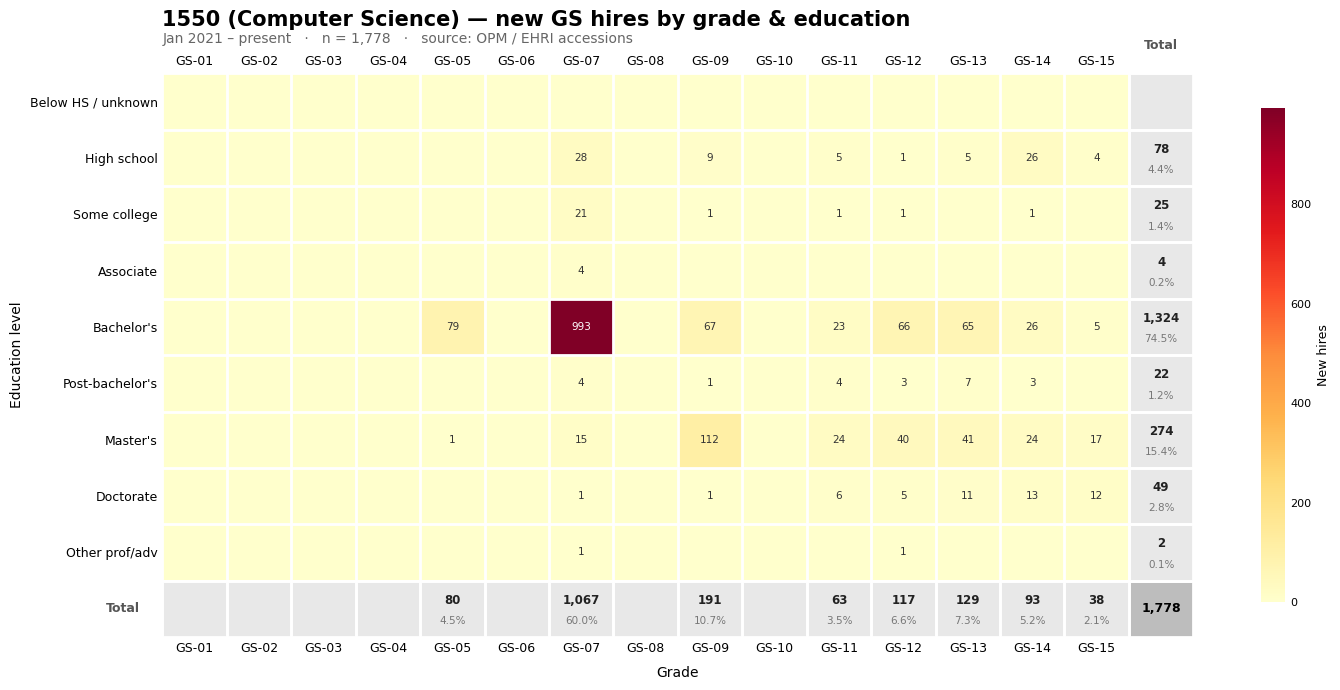

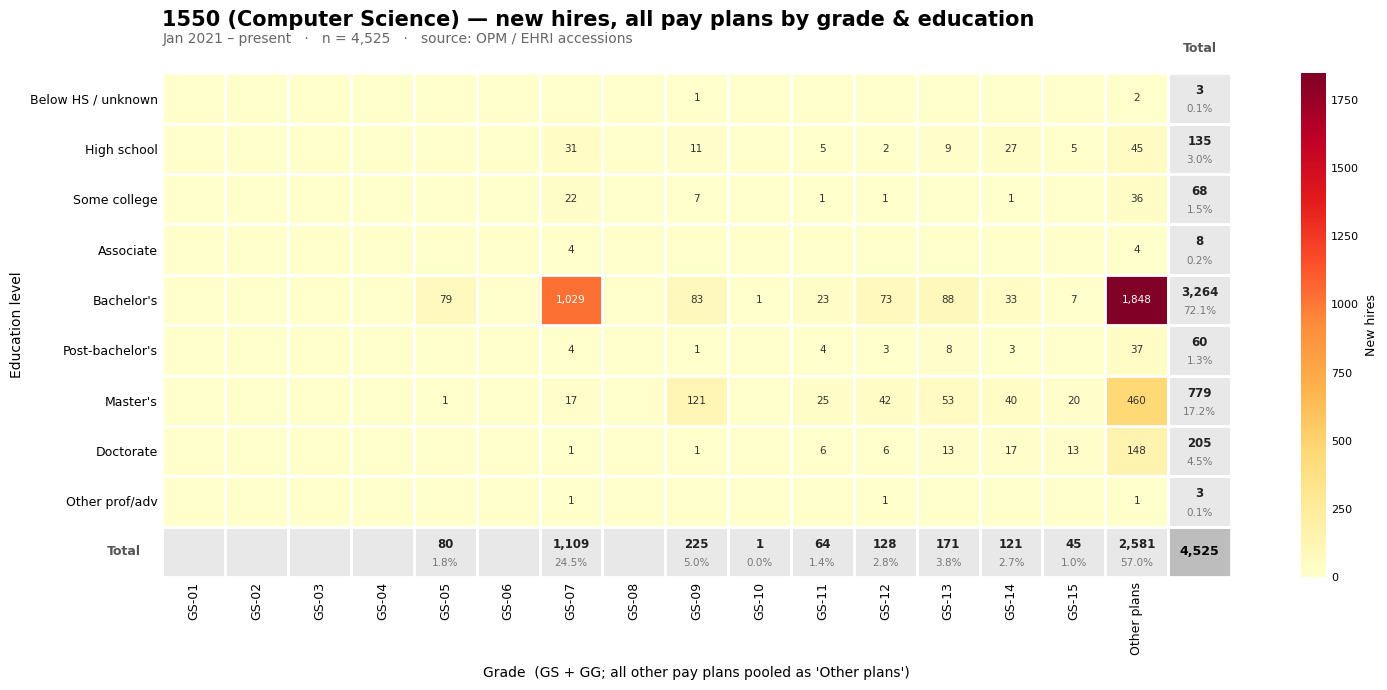

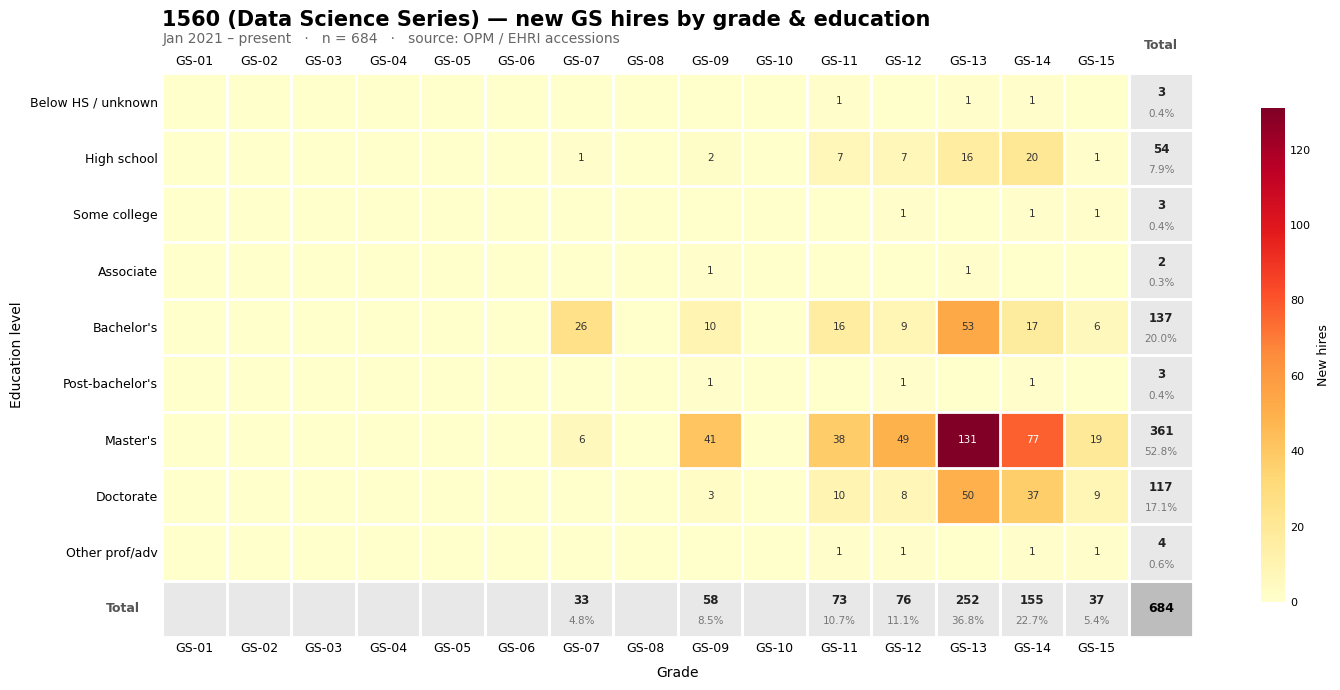

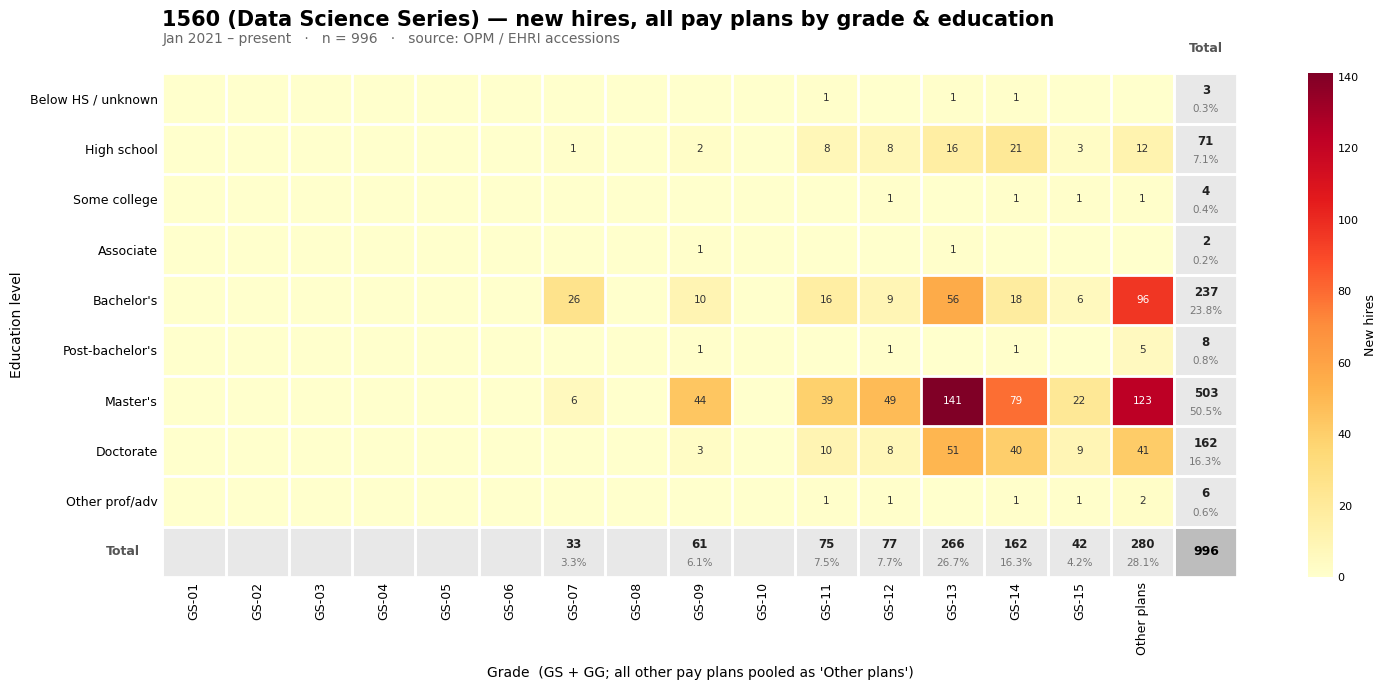

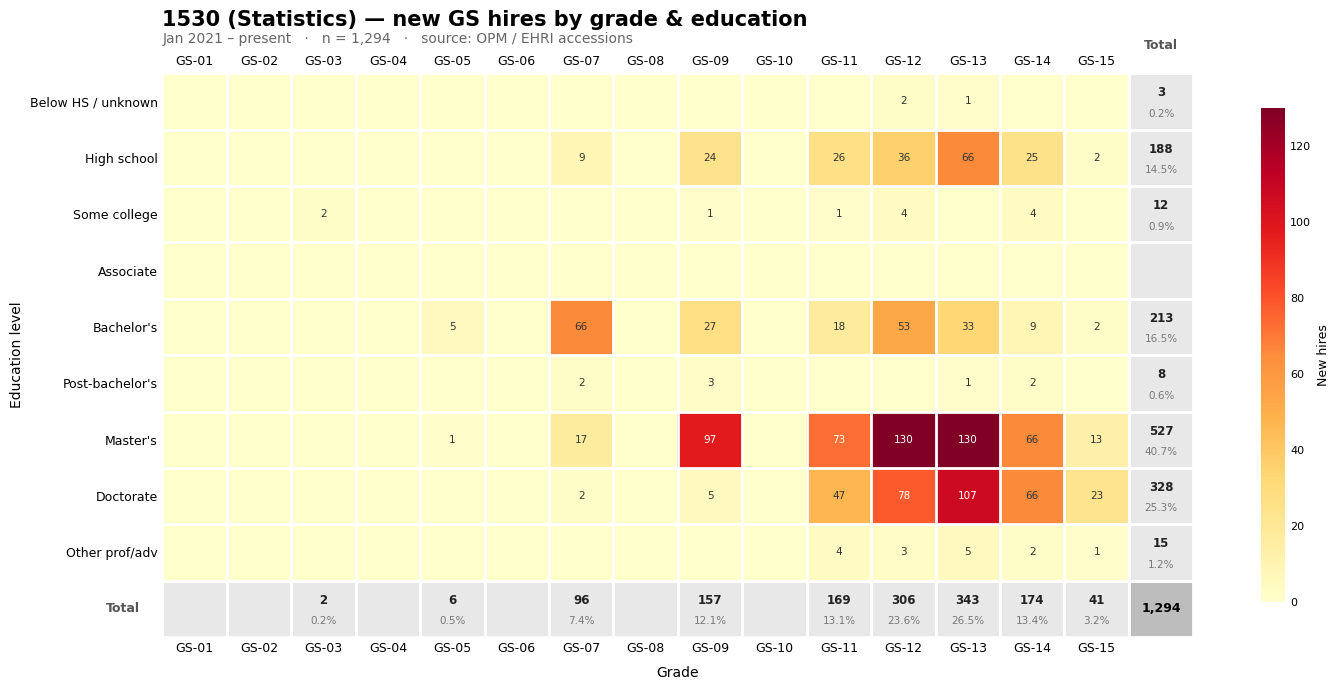

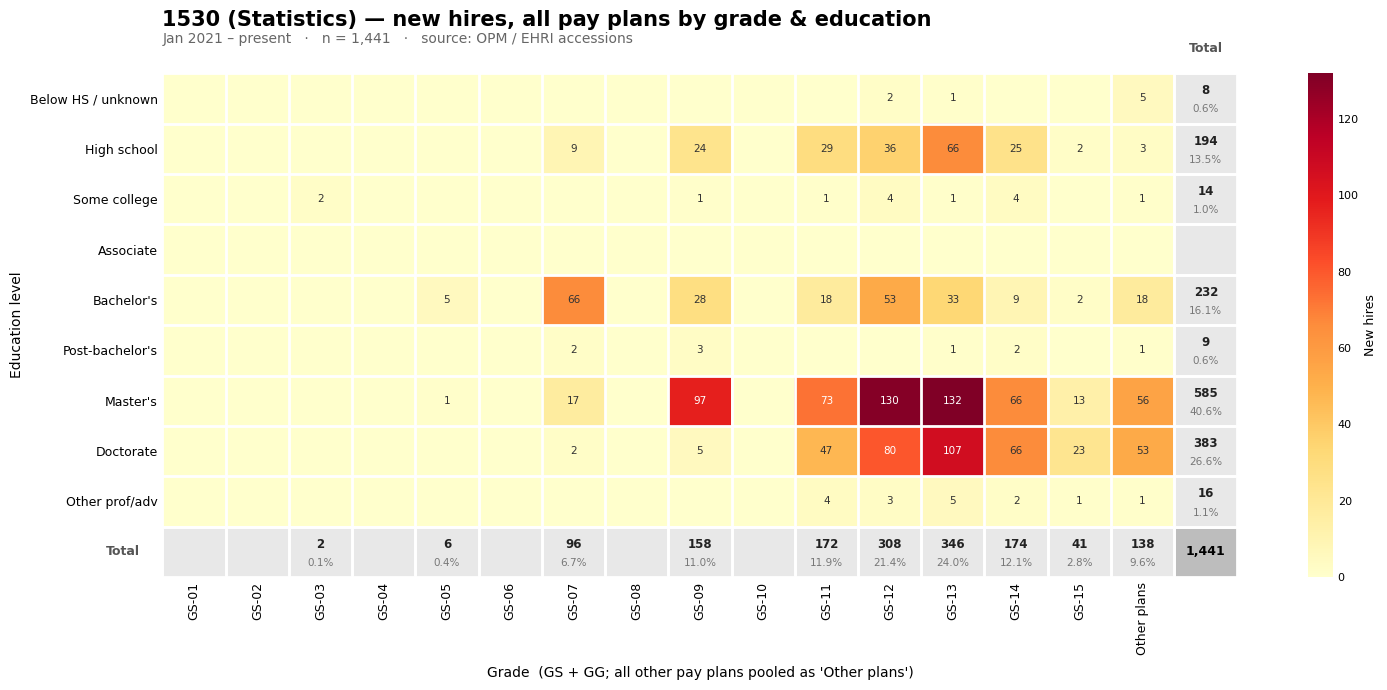

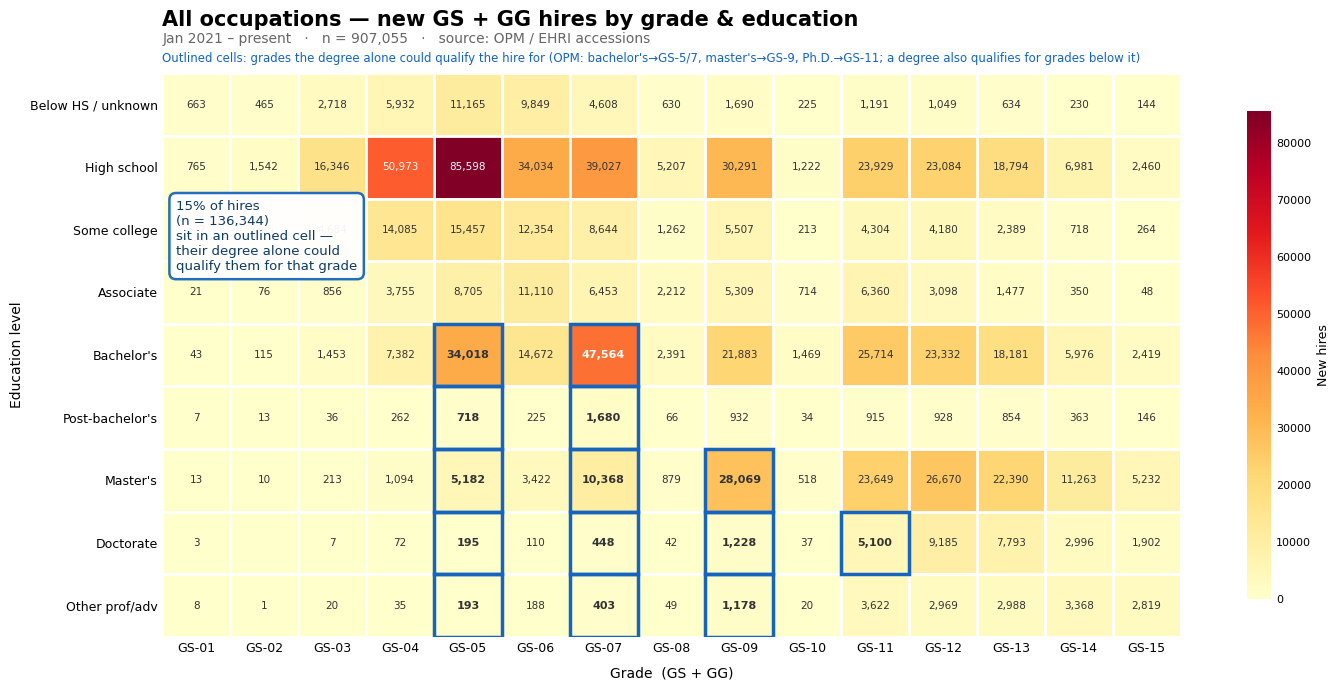

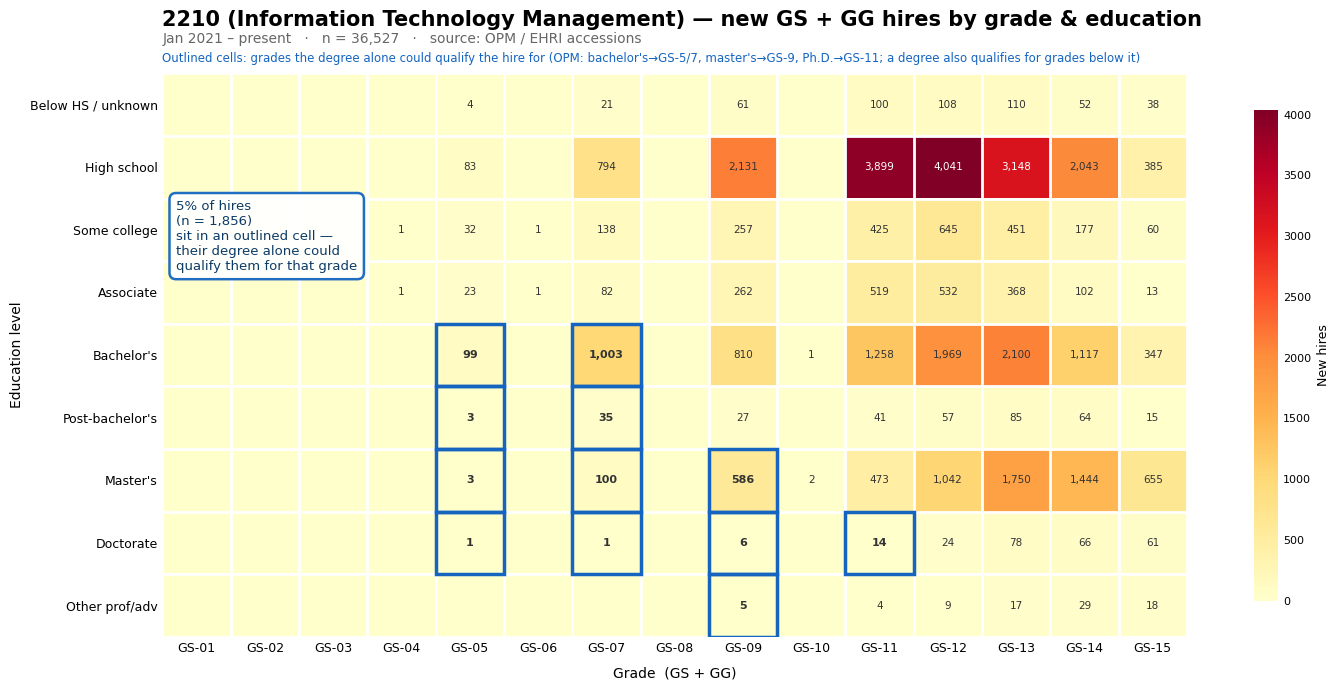

In [13]:
for code in SERIES:
    accession_heatmap(code, save=True)
    accession_heatmap(code, all_plans=True, save=True)

# qualifying-cells views (GS + GG, counts only, outlined, with share box)
accession_heatmap(pay_plans="gs+gg", totals=False, highlight_quals=True,
                  out="heatmap_overall_gsgg_quals.png")
accession_heatmap("2210", pay_plans="gs+gg", totals=False, highlight_quals=True,
                  out="heatmap_2210_gsgg_quals.png");

## Methodology & caveats

- **Unit:** OPM/EHRI *accessions* = personnel actions that add an employee to the federal workforce (new hires, transfers in). Each parquet row is pre-aggregated; figures use `SUM(count)`.
- **Window:** accession effective month `>= 202101` (Jan 2021). Change `START_MONTH` in `ehri_heatmaps.py` to adjust.
- **Education** is self-reported `education_level_code`, bucketed into the row labels shown. For series with no positive degree requirement (e.g. 2210), "High school" reflects the qualifying education recorded, not necessarily the employee's highest attainment.
- **Grade:** `pay_plans="gs"` shows only the General Schedule; `"gs+gg"` adds GG (same scale); `"all"` also pools every other pay plan into one "Other plans" column (demonstration/banded plans use bands like ND-02 that don't map to GS grades).
- **Qualifying-cell outlines** (`highlight_quals=True`) mark education≥the credential that opens each degree-entry grade under OPM's group-coverage standard: bachelor's→GS-5/7, master's→GS-9, Ph.D.→GS-11, with each degree also covering the lower entry grades (the staircase). The box sums those cells as a share of all hires shown. They flag where a degree *could* be the basis of qualification; they do not prove it was, and they exclude experience-based qualification. The small "Other prof/adv" bucket (first-professional, sixth-year) is treated as master's-level.
- **Latest months** are revised by OPM over time; re-running picks up the newest published version of each month automatically.